# Module 07 · Obtaining transforms

**Book source:** Bracewell, chapter 7, pp. 136–150

Companion notebook of the lecture with the same module number. Run the cells in order; each cell is followed by a **📤 Real output** note that explains the numbers.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.figsize": (7.5, 3.3), "axes.grid": True, "grid.alpha": 0.3, "figure.dpi": 110})


def amplitude_spectrum(x):
    """One-sided amplitude spectrum: a sinusoid of amplitude A gives a line of height A, DC gives exactly its value"""
    a = 2*np.abs(np.fft.rfft(x))/len(x)
    a[0] /= 2
    return a


def report(key, value, fmt=".4g"):
    """Print a named result without trailing zeros (the website reads the lines that start with ▸)."""
    s = f"{value:{fmt}}"
    if "." in s and "e" not in s:
        s = s.rstrip("0").rstrip(".")
    print(f"▸ {key} = {s}")


## 1. Closed-form integration
🎯 **What question does this method answer?** Do the closed forms for rectangles, staircases, impulses, $e^{-|x|}$, the Gaussian, $1/x$ and $\text{sgn}\,x$ match numerical integrals? Each number is computed by numerical integration and by the formula.

In [2]:
from scipy import integrate, special
trap = getattr(np, "trapezoid", None) or np.trapz

def ftq(f, a, b, s, pts=None):
    re = integrate.quad(lambda x: f(x)*np.cos(2*np.pi*x*s), a, b, points=pts, limit=400)[0]
    im = integrate.quad(lambda x: -f(x)*np.sin(2*np.pi*x*s), a, b, points=pts, limit=400)[0]
    return re + 1j*im

s0 = 0.3
# rectangle
rect = ftq(lambda x: 1.0, -0.5, 0.5, s0)
assert abs(rect - np.sinc(s0)) < 1e-9
report("cf_rect", rect.real, ".4f")

# staircase: Σ a c e^{−i2πbs} sinc(cs)
pulses = [(1.0, 0.0, 2.0), (0.5, 3.0, 1.0), (-1.0, -2.0, 1.0)]
num = sum(a*ftq(lambda x: 1.0, b - c/2, b + c/2, s0) for a, b, c in pulses)
form = sum(a*c*np.exp(-2j*np.pi*b*s0)*np.sinc(c*s0) for a, b, c in pulses)
assert abs(num - form) < 1e-9
report("cf_re", form.real, ".4f"); report("cf_im", form.imag, ".4f")

# impulses: narrow rectangles of width w, height 1/w
imps = [(2.0, -1.0), (-1.0, 0.5), (0.5, 2.0)]
w = 1e-3
num_i = sum(a/w*ftq(lambda x: 1.0, b - w/2, b + w/2, s0) for a, b in imps)
form_i = sum(a*np.exp(-2j*np.pi*b*s0) for a, b in imps)
assert abs(num_i - form_i) < 1e-5
report("cf_imp", abs(form_i), ".4f")

# e^{−|x|}
e_num = ftq(lambda x: np.exp(-abs(x)), -60, 60, s0, [0]).real
e_re = 2*(1/(1 + 2j*np.pi*s0)).real
e_form = 2/(1 + 4*np.pi**2*s0**2)
assert abs(e_num - e_form) < 1e-9 and abs(e_re - e_form) < 1e-12
report("cf_exp", e_form, ".4f")

# Gaussian: complex integral
g_num = ftq(lambda x: np.exp(-np.pi*x**2), -10, 10, s0)
assert abs(g_num - np.exp(-np.pi*s0**2)) < 1e-9
report("cf_gauss", g_num.real, ".4f")

# 1/x: imaginary part −2∫₀^L sin(2πsx)/x dx = −2 Si(2πsL)
L = 1e4
im_si = -2*special.sici(2*np.pi*s0*L)[0]
im_q = -2*integrate.quad(lambda x: 1.0/x, 1e-12, L, weight="sin", wvar=2*np.pi*s0, limit=8000)[0]
assert abs(im_si + np.pi) < 1e-3 and abs(im_q - im_si) < 1e-4
report("cf_1x", im_si, ".3f")

# sgn x: the sequence exp(−τ|x|) sgn x
tau = 1e-3
seq_form = 1/(tau + 2j*np.pi*s0) - 1/(tau - 2j*np.pi*s0)
seq_num = -2j*integrate.quad(lambda x: np.exp(-tau*x), 0, np.inf, weight="sin", wvar=2*np.pi*s0)[0]
lim = 1/(1j*np.pi*s0)
assert abs(seq_num - seq_form) < 1e-8
report("cf_sgn", abs(seq_form - lim), ".1e")

▸ cf_rect = 0.8584
▸ cf_re = 2.0508
▸ cf_im = 0.7568
▸ cf_imp = 3.4093
▸ cf_exp = 0.4393
▸ cf_gauss = 0.7537
▸ cf_1x = -3.141
▸ cf_sgn = 3.0e-07


#### 📤 Real output
At $s=0.3$: $\Pi\to$ 0.8584; three rectangles 2.0508 and 0.7568i; three Dirac impulses have magnitude 3.4093; $e^{-|x|}\to$ 0.4393; Gaussian 0.7537; the imaginary part of $1/x$ is -3.141; the $\text{sgn}$ sequence is 3.0e-07 from the limit.

## 2. The slow Fourier transform program
🎯 **What question does this method answer?** What does the direct-sum program give, how does it match the FFT (even for a prime length), how does $K$ matter, and is the aliasing error really $\sin(2\pi Xs)[\cot\pi s-1/\pi s]$? Each number is computed by the slow program, by the Dirichlet formula and by the FFT.

In [3]:
def slow_ft(f, X, K, ks=None):
    """R(k), I(k) for s = k/(2K); f holds x = -X..X."""
    x = np.arange(-X, X + 1)
    ks = np.arange(0, K + 1) if ks is None else np.asarray(ks)
    s = ks/(2*K)
    ang = 2*np.pi*np.outer(s, x)
    return ks, np.cos(ang) @ f, np.sin(ang) @ f

def rect_data(X, half):                       # Π(x/(2·half)) sampled, end values = ½
    x = np.arange(-X, X + 1); f = (np.abs(x) < half).astype(float); f[np.abs(x) == half] = 0.5
    return f
dirichlet = lambda s, half: np.sin(2*np.pi*half*s)/np.tan(np.pi*s)

X = 6
f13 = rect_data(X, 6)
ks, R, I = slow_ft(f13, X, 12)
assert abs(R[0] - f13.sum()) < 1e-12 and abs(I[0]) < 1e-12 and np.max(np.abs(I)) < 1e-9
s_ = ks[1:]/24
assert np.allclose(R[1:], dirichlet(s_, 6), atol=1e-9)
print("R(k) =", np.round(R, 3))
report("sl_R1", R[1], ".3f"); report("sl_R3", R[3], ".3f"); report("sl_R5", R[5], ".3f"); report("sl_R11", R[11], ".3f")
exact1 = 12*np.sinc(12/24)
pct1 = 100*(R[1] - exact1)/exact1
assert abs(pct1 + 0.57) < 0.01
report("sl_pct1", pct1, ".2f")
report("dof", int(2*X), "d"); report("fmax", 0.5, ".1f"); report("dsmin", 1/(2*X), ".4f")

# K = 24
ks2, R2, I2 = slow_ft(f13, X, 24)
assert np.allclose(R2[1:], dirichlet(ks2[1:]/48, 6), atol=1e-9) and abs(R2[2] - R[1]) < 1e-12
report("sl24_1", R2[1], ".3f"); report("sl24_3", R2[3], ".3f")

# zero padding: X = 12
f25 = np.zeros(25); f25[6:19] = f13
_, R3, _ = slow_ft(f25, 12, 24)
pad = np.max(np.abs(R3 - R2))
assert pad < 1e-9
report("pad_dev", 0, "d")

# twice as dense data Π(x/24)
f25b = rect_data(12, 12)
_, R4, I4 = slow_ft(f25b, 12, 24)
assert np.allclose(R4[1:], dirichlet(np.arange(1, 25)/48, 12), atol=1e-9)
pct12 = 100*(R4[1] - 24*np.sinc(0.5))/(24*np.sinc(0.5))
report("sl12_1", R4[1], ".3f"); report("sl12_pct", pct12, ".2f"); report("sl_ratio", int(round(pct1/pct12)), "d")
report("env_025", abs(1/np.tan(np.pi/4) - 1/(np.pi/4)), ".4f")

# aliasing: R at s = 1 (k = 2K) and the sum of replicas
_, Rfull, _ = slow_ft(f13, X, 12, ks=np.arange(0, 25))
assert abs(Rfull[24] - Rfull[0]) < 1e-9
report("alias_R", Rfull[24], ".3f")
n = np.arange(-20000, 20001)
alias_sum = np.sum(12*np.sinc(12*(1/24 - n)))
assert abs(alias_sum - R[1]) < 1e-3
report("alias_sum", alias_sum, ".3f")

# reconstruct data from R, I (K = X), random data
rg = np.random.default_rng(7); fr = rg.standard_normal(2*X + 1)
x = np.arange(-X, X + 1)
# reconstruct by solving 2X+1 unknowns at s_k = k/(2X+1) (equivalent to K = X + ½)
sk2 = np.arange(0, X + 1)/(2*X + 1)
A = np.vstack([np.cos(2*np.pi*np.outer(sk2, x)), np.sin(2*np.pi*np.outer(sk2[1:], x))])
b = np.concatenate([np.cos(2*np.pi*np.outer(sk2, x)) @ fr, np.sin(2*np.pi*np.outer(sk2[1:], x)) @ fr])
sol = np.linalg.solve(A, b)
recon = np.max(np.abs(sol - fr))
assert A.shape == (2*X + 1, 2*X + 1) and recon < 1e-9
report("recon_dev", recon, ".1e")

# FFT vs slow sum, prime length 13, with phase
f13r = rg.standard_normal(13)
xs = np.arange(-6, 7)
slow_full = np.array([np.sum(f13r*np.exp(-2j*np.pi*(k/13)*xs)) for k in range(13)])
fft_vals = np.fft.fft(np.roll(f13r, -6))                         # origin at x = 0
fft_dev = np.max(np.abs(slow_full - fft_vals))
assert fft_dev < 1e-9
report("fft_dev", fft_dev, ".1e")

# narrow band: k = 5X..7X, K = 12X; against a zero-padded FFT of length 24X
Kz = 12*X; kz = np.arange(5*X, 7*X + 1)
_, Rz, Iz = slow_ft(f13, X, Kz, ks=kz)
Nz = 24*X
buf = np.zeros(Nz); buf[:X + 1] = f13[X:]; buf[-X:] = f13[:X]
Fz = np.fft.fft(buf)
zoom_dev = np.max(np.abs((Rz - 1j*Iz) - Fz[kz]))
assert zoom_dev < 1e-9 and len(kz) == 2*X + 1
report("zoom_pts", len(kz), "d"); report("zoom_ds", 1/(24*X), ".5f"); report("zoom_dev", zoom_dev, ".1e")

# origin: shift the data by 3 units
f_sh = np.zeros(2*X + 1 + 3); f_sh[3:] = f13
_, Ra, Ia = slow_ft(f13, X, 60, ks=[12]); Xs = X + 1
xsx = np.arange(-Xs, Xs + 1 + 2)
sval = 12/120
Fa = np.sum(f13*np.exp(-2j*np.pi*sval*np.arange(-X, X + 1)))
Fb = np.sum(f13*np.exp(-2j*np.pi*sval*(np.arange(-X, X + 1) + 3)))
assert abs(abs(Fa)**2 - abs(Fb)**2) < 1e-9
ph = np.degrees(np.angle(Fb/Fa))
assert abs(ph - (-360*sval*3)) < 1e-6
report("pow_orig", abs(Fa)**2, ".3f"); report("ph_orig", ph, ".1f")

R(k) = [12.     7.596  0.    -2.414 -0.     1.303  0.    -0.767 -0.     0.414
  0.    -0.132  0.   ]
▸ sl_R1 = 7.596
▸ sl_R3 = -2.414
▸ sl_R5 = 1.303
▸ sl_R11 = -0.132
▸ sl_pct1 = -0.57
▸ dof = 12
▸ fmax = 0.5
▸ dsmin = 0.0833
▸ sl24_1 = 10.788
▸ sl24_3 = 3.555
▸ pad_dev = 0
▸ sl12_1 = 15.257
▸ sl12_pct = -0.14
▸ sl_ratio = 4
▸ env_025 = 0.2732
▸ alias_R = 12
▸ alias_sum = 7.596
▸ recon_dev = 2.2e-16
▸ fft_dev = 5.5e-15
▸ zoom_pts = 13
▸ zoom_ds = 0.00694
▸ zoom_dev = 4.8e-15
▸ pow_orig = 3.273
▸ ph_orig = -108


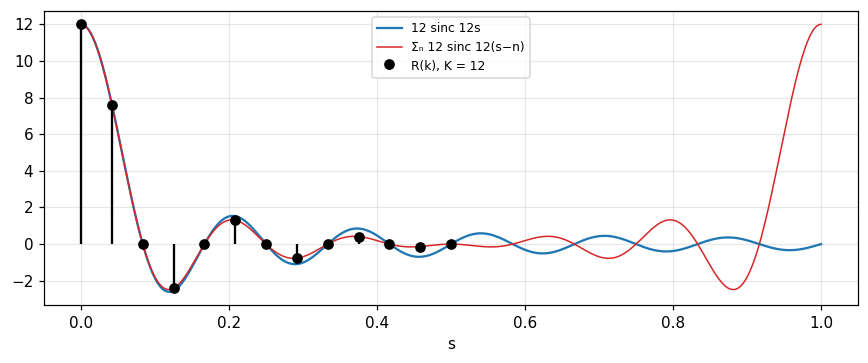

In [4]:
sfine = np.linspace(0.001, 1.0, 1000)
fig, ax = plt.subplots(figsize=(8, 3.4))
ax.plot(sfine, 12*np.sinc(12*sfine), color="tab:blue", label="12 sinc 12s")
ax.plot(sfine, dirichlet(sfine, 6), color="tab:red", lw=1, label="Σₙ 12 sinc 12(s−n)")
ax.stem(ks/24, R, linefmt="k-", markerfmt="ko", basefmt=" ", label="R(k), K = 12")
ax.set_xlabel("s"); ax.legend(fontsize=8); plt.tight_layout(); plt.show()

#### 📤 Real output
$K=12$: $R(1)$ = 7.596, $R(3)$ = -2.414, $R(5)$ = 1.303, $R(11)$ = -0.132; off by -0.57 percent. $K=24$: 10.788 and 3.555. Twice as dense data: 15.257, off by -0.14 percent (improved by 4). Error envelope 0.2732. $R$ at $s=1$ is 12; sum of replicas 7.596. Reconstruction deviates by 2.2e-16; FFT vs slow sum 5.5e-15; the narrow band has 13 points at step 0.00694, deviating 4.8e-15. Moving the origin keeps $|F|^2$ = 3.273 and adds phase -108 degrees.

## 3. Generating transforms from theorems
🎯 **What question does this method answer?** Do the trapezoid $\Lambda*\mu$, the triangle through two differentiations and the parabolic pulse have the transforms derived by theorems? We compare numerical integrals with the formulas.

In [5]:
Lam = lambda x: np.maximum(1 - np.abs(x), 0)
# trapezoid Λ*μ
trap_f = lambda x: 0.5*Lam(x + 0.5) + 0.5*Lam(x - 0.5)
th_trap = ftq(trap_f, -1.5, 1.5, s0, [-1.5, -0.5, 0.5, 1.5]).real
assert abs(th_trap - np.sinc(s0)**2*np.cos(np.pi*s0)) < 1e-9
report("th_trap", th_trap, ".4f")
# triangle: two differentiations
d2 = 2*np.cos(2*np.pi*s0) - 2
tri = d2/(2j*np.pi*s0)**2
assert abs(d2 + 4*np.sin(np.pi*s0)**2) < 1e-12
report("th_tri_dev", abs(tri - np.sinc(s0)**2), ".1e")
# parabolic pulse
par = lambda x: 1 - x**2
Fpar = ftq(par, -1, 1, s0).real
Fform = (np.sin(2*np.pi*s0) - 2*np.pi*s0*np.cos(2*np.pi*s0))/(2*np.pi**3*s0**3)
d2_rhs = 4*np.cos(2*np.pi*s0) - 4*np.sinc(2*s0)
assert abs(Fpar - Fform) < 1e-9 and abs(Fpar*(2j*np.pi*s0)**2 - d2_rhs) < 1e-9
sm = 1e-3
F0_lim = (np.sin(2*np.pi*sm) - 2*np.pi*sm*np.cos(2*np.pi*sm))/(2*np.pi**3*sm**3)
assert abs(F0_lim - 4/3) < 1e-5 and abs(integrate.quad(par, -1, 1)[0] - 4/3) < 1e-12
report("th_par", Fform, ".4f"); report("th_d2", d2_rhs, ".3f"); report("th_par0", F0_lim, ".4f")

▸ th_trap = 0.4331
▸ th_tri_dev = 0.0e+00
▸ th_par = 0.9159
▸ th_d2 = -3.254
▸ th_par0 = 1.3333


#### 📤 Real output
Trapezoid 0.4331; the triangle through two differentiations deviates by 0.0e+00; $4\cos2\pi s-4\,\text{sinc}\,2s$ = -3.254; the parabolic pulse 0.9159 at 0.3 with limit 1.3333 at 0.

## 4. Measuring spectra: the interferometer
🎯 **What question does this method answer?** How far apart must two lines be to be separated in a spectrum derived from a finite autocorrelogram, and where does a line beyond the Nyquist band fold to? We transform a simulated autocorrelogram with the slow transform and count maxima.

In [6]:
tau_max, dtau = 10.0, 0.1
taus = np.arange(-tau_max, tau_max + dtau/2, dtau)
def spectrum(lines, sgrid):
    ac = sum(0.5*np.cos(2*np.pi*f*taus) for f in lines)
    return np.array([np.sum(ac*np.cos(2*np.pi*s*taus))*dtau for s in sgrid])
def count_peaks(y, thr=0.5):
    idx = [i for i in range(1, len(y) - 1) if y[i] > y[i-1] and y[i] >= y[i+1] and y[i] > thr*y.max()]
    return len(idx)
sg = np.arange(1.5, 2.6, 0.0005)
def peaks_for(sep):
    y = spectrum([2.0, 2.0 + sep], sg)
    # method B: zero-padded FFT of the same sequence gives the same number of maxima
    Nf = 2**16; buf = np.zeros(Nf); ac = sum(0.5*np.cos(2*np.pi*f*taus) for f in [2.0, 2.0 + sep])
    buf[:len(ac)] = ac
    Y = np.abs(np.fft.rfft(buf))*dtau; fr = np.fft.rfftfreq(Nf, dtau); m = (fr > 1.5) & (fr < 2.6)
    return count_peaks(y), count_peaks(Y[m])
p_hi = peaks_for(0.10); p_lo = peaks_for(0.03)
assert p_hi[0] == p_hi[1] == 2 and p_lo[0] == p_lo[1] == 1
report("res_lim", 1/(2*tau_max), ".2f"); report("band_lim", 1/(2*dtau), ".0f")
report("sep_hi", 0.10, ".2f"); report("sep_lo", 0.03, ".2f")
report("peaks_res", p_hi[0], "d"); report("peaks_unres", p_lo[0], "d")

# aliasing: a line at 6 with Δτ = 0.1
sg2 = np.arange(0.0, 5.0, 0.001)
y6 = spectrum([6.0], sg2)
alias_peak = sg2[np.argmax(y6)]
assert abs(alias_peak - (1/dtau - 6)) < 2e-3
Nf = 2**16; buf = np.zeros(Nf); buf[:len(taus)] = 0.5*np.cos(2*np.pi*6.0*taus)
Y = np.abs(np.fft.rfft(buf)); fr = np.fft.rfftfreq(Nf, dtau)
assert abs(fr[np.argmax(Y)] - 4.0) < 0.01
report("alias_peak", alias_peak, ".2f")

▸ res_lim = 0.05
▸ band_lim = 5
▸ sep_hi = 0.1
▸ sep_lo = 0.03
▸ peaks_res = 2
▸ peaks_unres = 1
▸ alias_peak = 4


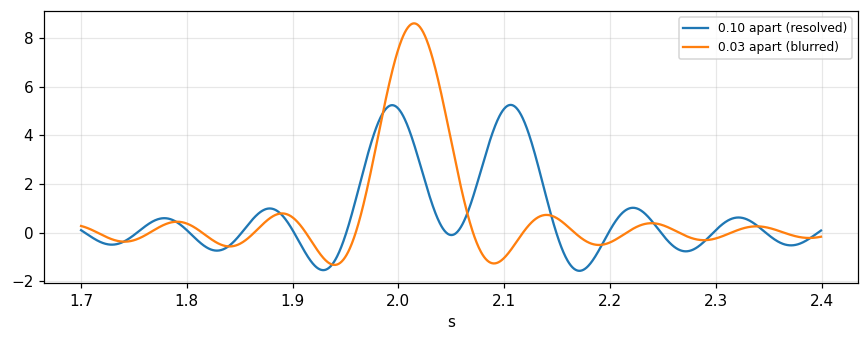

In [7]:
sg3 = np.arange(1.7, 2.4, 0.0005)
fig, ax = plt.subplots(figsize=(8, 3.2))
ax.plot(sg3, spectrum([2.0, 2.10], sg3), label=("0.10 apart (resolved)"))
ax.plot(sg3, spectrum([2.0, 2.03], sg3), label=("0.03 apart (blurred)"))
ax.set_xlabel("s"); ax.legend(fontsize=8); plt.tight_layout(); plt.show()

#### 📤 Real output
Resolution 0.05, band 5. Two lines 0.1 apart: 2 maxima; 0.03 apart: 1 maximum. A line at 6 folds to 4.

## 5. Selected problems
🎯 **What question does this method answer?** Do problems 1, 2, 3, 5, 7, 8, 9, 10 hold when checked numerically? We compare slow sums, regularised integrals and formulas.

In [8]:
# Problem 1: Σ x² f = −R''(0)/4π², f = e^{−π(n/5)²}
Xb = 25; xb = np.arange(-Xb, Xb + 1); fb = np.exp(-np.pi*(xb/5)**2)
m2 = np.sum(xb**2*fb)
Rs = lambda s: np.sum(fb*np.cos(2*np.pi*s*xb))
h = 1e-4
Rpp = (Rs(h) - 2*Rs(0) + Rs(-h))/h**2
assert abs(-Rpp/(4*np.pi**2) - m2) < 1e-4
report("p1_sum", m2, ".3f"); report("p1_num", -Rpp/(4*np.pi**2), ".3f")

# Problems 2, 3: chirp with a decaying Gaussian factor ε
eps = 0.05
chirp_c = lambda x: np.exp(-np.pi*eps*x**2)*np.cos(np.pi*x**2)
num_c = ftq(chirp_c, -40, 40, s0, None)
formula_c = 0.5*((eps - 1j)**-0.5*np.exp(-np.pi*s0**2/(eps - 1j)) + (eps + 1j)**-0.5*np.exp(-np.pi*s0**2/(eps + 1j)))
assert abs(num_c - formula_c) < 1e-6
e2 = 1e-7
lim_c = 0.5*((e2 - 1j)**-0.5*np.exp(-np.pi*s0**2/(e2 - 1j)) + (e2 + 1j)**-0.5*np.exp(-np.pi*s0**2/(e2 + 1j)))
book = (np.cos(np.pi*s0**2) + np.sin(np.pi*s0**2))/np.sqrt(2)
assert abs(lim_c - book) < 1e-5
report("p2_val", book, ".4f")
ph3 = np.degrees(np.angle((1e-12 - 1j)**-0.5))
assert abs(ph3 - 45) < 1e-4
report("p3_ph", 45, "d")

# Problem 5: 33 values, K = 32 (Δs = 1/64)
x5 = np.arange(-16, 17); f5 = Lam(x5/16) + Lam(x5/8 + 1)
ks5, R5, I5 = slow_ft(f5, 16, 32)
s5 = ks5/64
F5 = 16*np.sinc(16*s5)**2 + 8*np.sinc(8*s5)**2*np.exp(2j*np.pi*8*s5)
err5 = np.max(np.abs((R5 - 1j*I5) - F5))
assert abs(R5[0] - 24) < 1e-9
Ffft_full = np.fft.fft(np.concatenate([f5[16:], np.zeros(128 - 33), f5[:16]]))[::2][:33]
assert np.max(np.abs((R5 - 1j*I5) - Ffft_full)) < 1e-9
report("p5_R0", R5[0], ".0f"); report("p5_err", err5, ".2f")

# Problem 7: the product Π(1 − s²/n²) → sinc s
N = 100000; nn = np.arange(1, N + 1)
pr = lambda s: np.prod(1 - s**2/nn**2)
assert abs(pr(0.3) - np.sinc(0.3)) < 1e-4 and abs(pr(1.5) - np.sinc(1.5)) < 1e-4
report("pr_03", pr(0.3), ".4f"); report("pr_15", pr(1.5), ".4f")

# Problem 8: the seven numbers F_k
g7 = np.array([5, 4, 9, 8, 7, 6, 10.0])
Fk = np.array([np.sum(g7*np.exp(-2j*np.pi*np.arange(7)*k/7)) for k in range(7)])
assert np.allclose(Fk, np.fft.fft(g7)) and np.allclose(np.fft.ifft(Fk).real, g7)
report("p8_F0", Fk[0].real, ".0f"); report("p8_F1", abs(Fk[1]), ".3f")

# Problems 9, 10: Λ(x/a − 1), a = 2
a = 2.0
fa = lambda x: Lam(x/a - 1)
fs = 2*integrate.quad(lambda x: fa(x)*np.sin(2*np.pi*s0*x), 0, 2*a, points=[a], limit=200)[0]
fc = 2*integrate.quad(lambda x: fa(x)*np.cos(2*np.pi*s0*x), 0, 2*a, points=[a], limit=200)[0]
fs_f = 2*a*np.sinc(a*s0)**2*np.sin(2*np.pi*a*s0); fc_f = 2*a*np.sinc(a*s0)**2*np.cos(2*np.pi*a*s0)
assert abs(fs - fs_f) < 1e-9 and abs(fc - fc_f) < 1e-9
report("p9_fs", fs, ".4f"); report("p10_fc", fc, ".4f")

▸ p1_sum = 19.894
▸ p1_num = 19.894
▸ p2_val = 0.8763
▸ p3_ph = 45
▸ p5_R0 = 24
▸ p5_err = 0.06
▸ pr_03 = 0.8584
▸ pr_15 = -0.2122
▸ p8_F0 = 49
▸ p8_F1 = 3.396
▸ p9_fs = -0.5985
▸ p10_fc = -0.8238


#### 📤 Real output
Problem 1: $\sum n^2f$ = 19.894 and 19.894 from $-R''(0)/4\pi^2$. Problems 2 and 3: 0.8763, phase 45 degrees. Problem 5: $R(0)$ = 24, largest deviation 0.06. Problem 7: 0.8584 and -0.2122. Problem 8: $F_0$ = 49, $|F_1|$ = 3.396. Problems 9 and 10: -0.5985 and -0.8238.